In [21]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sn 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = sn.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
df.drop(['deck', 'embarked','who','alive', 'class'], axis= 1 , inplace = True)

<Axes: xlabel='age', ylabel='Count'>

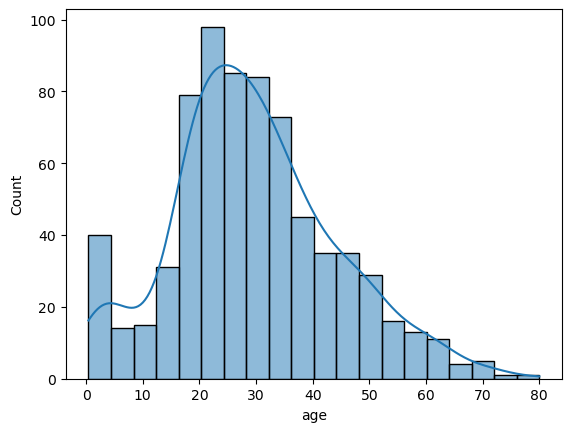

In [9]:
sn.histplot(df['age'] , kde = True , palette= "rainbow")

In [10]:
df['age'] = df['age'].fillna(df['age'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

<Axes: xlabel='survived', ylabel='count'>

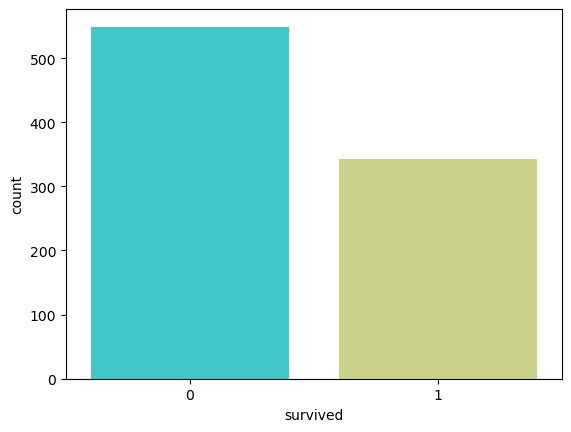

In [11]:
sn.countplot(x = 'survived' , data = df , palette='rainbow')

In [12]:
df['survived'].value_counts(normalize=True)* 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

<Axes: xlabel='sex', ylabel='survived'>

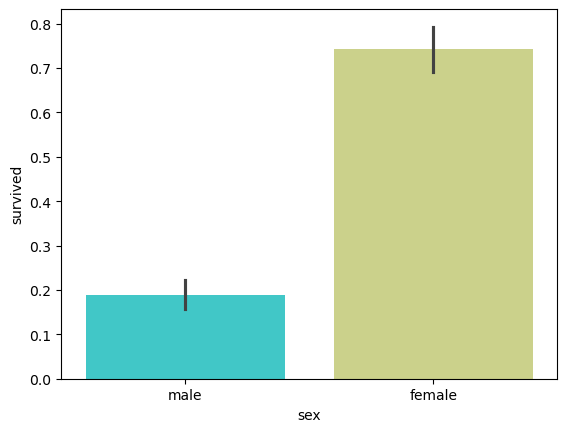

In [13]:
sn.barplot(x  = df['sex'] ,y = df['survived'] , palette= 'rainbow' ) 

<Axes: xlabel='pclass', ylabel='survived'>

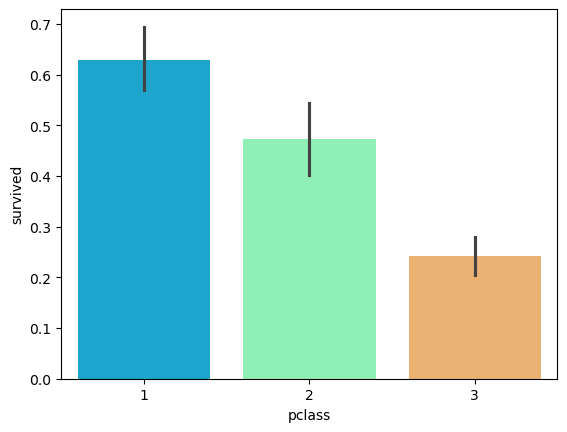

In [14]:
sn.barplot( x = df['pclass'] , y = df['survived'] , palette='rainbow')

<Axes: xlabel='sex', ylabel='age'>

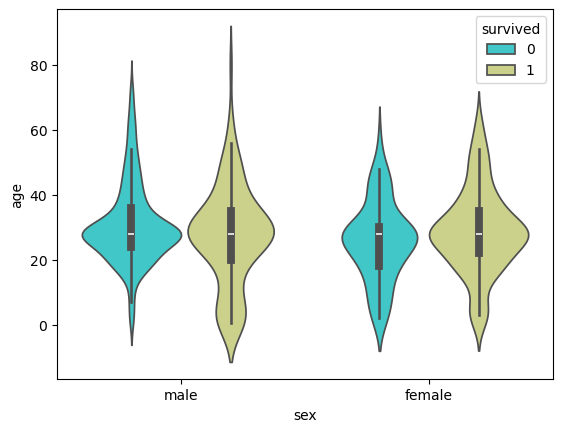

In [15]:
sn.violinplot(x = df['sex'] , y = df['age'] , hue = df['survived'] , palette='rainbow')

<Axes: xlabel='fare', ylabel='Count'>

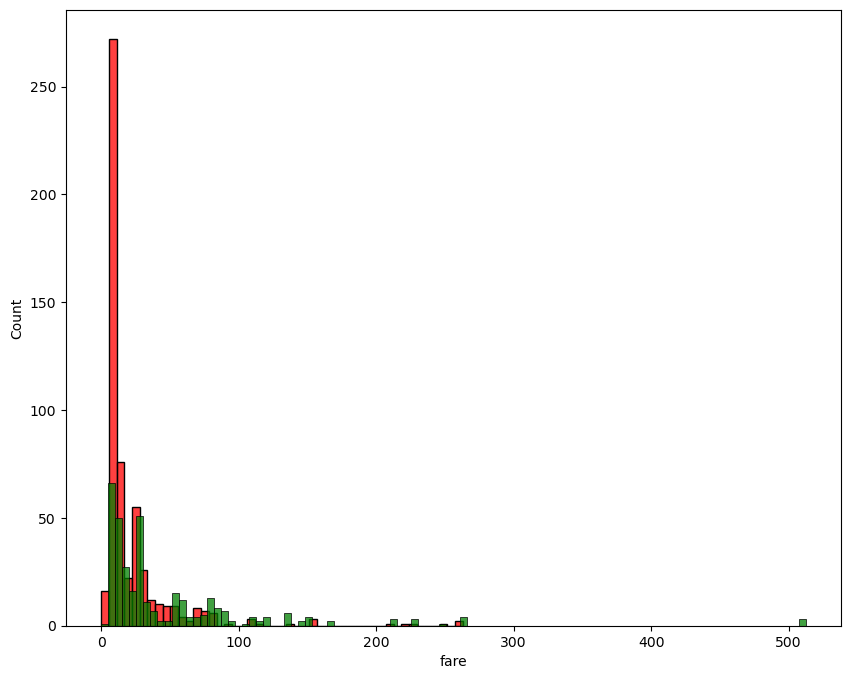

In [16]:
plt.figure(figsize = (10 , 8))
sn.histplot(df[df['survived'] == 0] ['fare'], color='red')
sn.histplot(df[df['survived'] == 1] ['fare'], color='green' , bins = 100)

<Axes: xlabel='sibsp', ylabel='survived'>

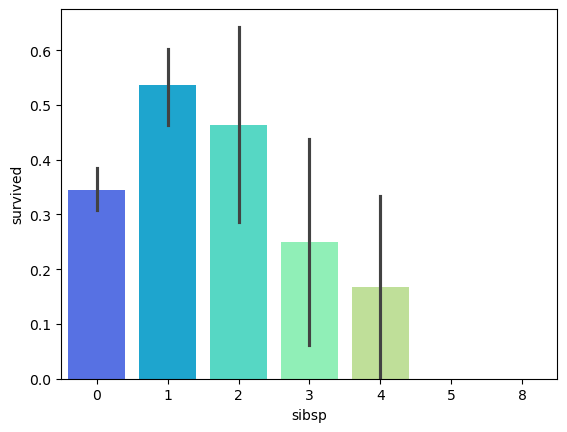

In [17]:
sn.barplot(x = df['sibsp'] ,y = df['survived'] , palette='rainbow')

<Axes: xlabel='parch', ylabel='survived'>

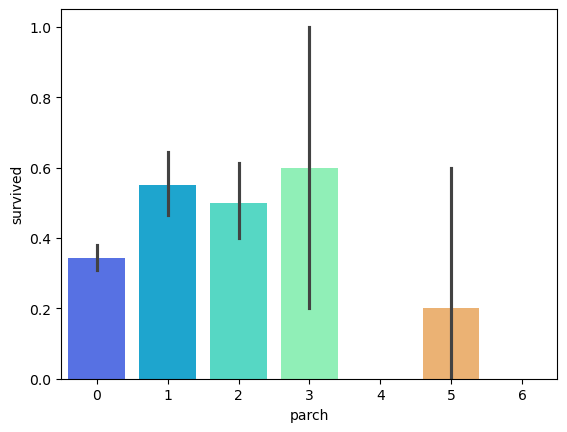

In [18]:
sn.barplot(x= df['parch'] , y = df['survived'] , palette = 'rainbow')

<Axes: xlabel='embark_town', ylabel='survived'>

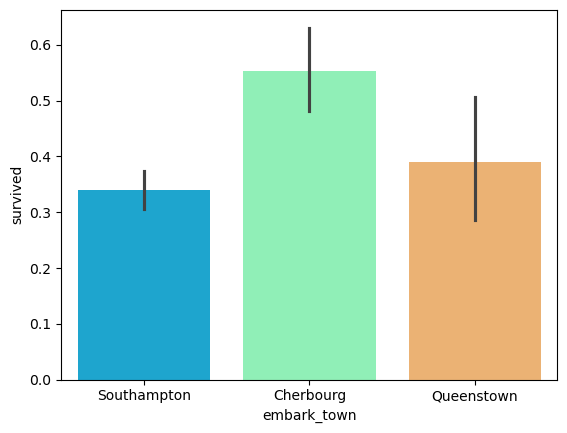

In [19]:
sn.barplot(x = df['embark_town'] , y = df['survived'] , palette='rainbow')

In [24]:
df_encode = pd.get_dummies(df , columns = ['sex' , 'embark_town', 'alone'] , drop_first = True)
df_encode

,survived,pclass,age,sibsp,parch,fare,adult_male,sex_male,embark_town_Queenstown,embark_town_Southampton,alone_True
0,0,3,22.0,1,0,7.2500,True,True,False,True,False
1,1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,False,True,True
3,1,1,35.0,1,0,53.1000,False,False,False,True,False
4,0,3,35.0,0,0,8.0500,True,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,True,False,True,True
887,1,1,19.0,0,0,30.0000,False,False,False,True,True
888,0,3,28.0,1,2,23.4500,False,False,False,True,False
889,1,1,26.0,0,0,30.0000,True,True,False,False,True


In [27]:
X = df_encode.drop(['survived'],axis = 1)
y = df_encode['survived']

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix , f1_score

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [33]:
model = LogisticRegression(max_iter= 500)

In [34]:
model.fit(X_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [36]:
y_pred  = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [40]:
accuracy_LR = accuracy_score(y_test , y_pred)
accuracy_LR

0.8156424581005587

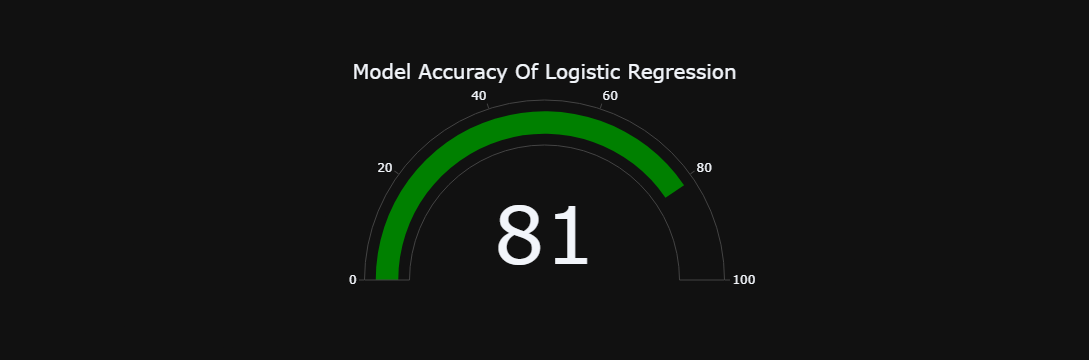

In [42]:
import plotly.graph_objects as go

accuracy = 0.81

fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = accuracy * 100,
    title = {'text': "Model Accuracy Of Logistic Regression"},
    gauge = {
        'axis': {'range': [0, 100]}
    }
))
fig.update_layout(template = 'plotly_dark')
fig.show()